# 02 — Topic Modeling
Uses BERTopic to discover topics in the AI news corpus, maps topics to industries, and saves labeled data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from pathlib import Path

for d in ["models", "outputs", "figures"]:
    Path(d).mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

In [2]:
df = pd.read_parquet("data/news_clean_ai.parquet")
print(f"Loaded {len(df):,} articles")

# Sample for speed — BERTopic embedding is O(N)
SAMPLE_N = 30_000
df_sample = df.sample(n=min(SAMPLE_N, len(df)), random_state=42).reset_index(drop=True)
docs = df_sample["article_text"].tolist()
print(f"Using {len(docs):,} articles for topic modeling")

Loaded 166,636 articles
Using 30,000 articles for topic modeling


In [7]:
from sklearn.feature_extraction.text import CountVectorizer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=5,
    ngram_range=(1, 2)
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    min_topic_size=80,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

df_sample["topic"] = topics
df_sample["topic_prob"] = probs

print(f"Number of topics found (excl. outlier -1): {topic_model.get_topic_info().shape[0] - 1}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-05-20 18:00:54,809 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/938 [00:00<?, ?it/s]

2026-05-20 18:24:40,697 - BERTopic - Embedding - Completed ✓
2026-05-20 18:24:40,698 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-20 18:24:50,798 - BERTopic - Dimensionality - Completed ✓
2026-05-20 18:24:50,802 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-20 18:24:57,749 - BERTopic - Cluster - Completed ✓
2026-05-20 18:24:57,760 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-05-20 18:26:09,551 - BERTopic - Representation - Completed ✓


Number of topics found (excl. outlier -1): 50


In [8]:
# ── inspect topic keywords ────────────────────────────────────────────────────
topic_info = topic_model.get_topic_info()
topic_info.to_csv("outputs/topic_info.csv", index=False)

# Export keyword table — use this to decide your manual labels below
topic_keywords_rows = []
for topic_id in topic_info["Topic"].unique():
    if topic_id == -1:
        continue
    words = topic_model.get_topic(topic_id)
    if words:
        keywords = ", ".join([w for w, _ in words[:10]])
        topic_keywords_rows.append({"topic": topic_id, "keywords": keywords})

topic_keywords_df = pd.DataFrame(topic_keywords_rows)
topic_keywords_df.to_csv("outputs/topic_keywords.csv", index=False)

# Print top 20 so you can read them and build your label map
print(topic_keywords_df.head(20).to_string(index=False))

 topic                                                                                                            keywords
     0                              gray, ai, gray media, prnewswire, media group, group, media, press release, data, 2023
     1                                                     india, share, ai, news, 2025, indian, today, world, 2026, delhi
     2                                    health, medical, healthcare, care, patients, patient, clinical, cancer, ai, news
     3                                                   chatgpt, openai, ai, gpt, users, new, news, like, google, chatbot
     4                    ai, data, security, business, generative, generative ai, technology, new, enterprise, management
     5         ment, products, overviewview, services, consumer, entertain ment, entertain, general, ment media, resources
     6                                         ago, hours ago, hours, weather, news, stories, video, ago video, file, 2023
     7          

In [11]:
TOPIC_LABELS = {
    0:  "Noise / Press Release Aggregator",
    1:  "India AI Market & News",
    2:  "Healthcare AI & Medical Diagnostics",
    3:  "ChatGPT & Conversational AI",
    4:  "Enterprise AI & Data Security",
    5:  "Noise / Web Artifact",
    6:  "Noise / Weather & General News Feed",
    7:  "Noise / NPR Radio Content",
    8:  "AI Chips & Semiconductor Industry",
    9:  "China AI & DeepSeek",
    10: "AI in Media & Creative Content",
    11: "Noise / Financial Market Data Feed",
    12: "Noise / Newswire Distribution",
    13: "Middle East AI Adoption (UAE/Saudi)",
    14: "Crypto & AI Investment",
    15: "OpenAI & Microsoft Business News",
    16: "AI Ethics & Human Intelligence",
    17: "Elon Musk / xAI / Grok",
    18: "Sam Altman & OpenAI Leadership",
    19: "AI in Banking & Financial Services",
    20: "Africa AI Adoption",
    21: "AI in Music & Entertainment",
    22: "Noise / Cookie Consent Web Artifact",
    23: "Noise / Newsletter & Advertising",       # webpronews, advertise, marketing
    24: "Noise / Product Hunt Listings",          # product hunt, rank, guidechecklists
    25: "Noise / Consumer Electronics Reviews",   # samsung, galaxy, iphone, zdnet
    26: "Google Gemini & AI Models",              # gemini, google gemini, model
    27: "Noise / Stock Watchlist Feed",           # nasdaq, quotes, watchlist, symbols
    28: "Noise / Crypto Trading Feed",            # mexc, aitech, trading, crypto
    29: "Noise / Nasdaq Market Feed",             # nasdaq, symbols, markets 
    30: "Apple AI & Siri Intelligence",           # apple intelligence, siri, tim cook
    31: "Noise / Forex Trading Feed",             # ea, usd, gold, advisor, indicator
    32: "AI in Science & Research",               # machine learning, space, satellite, researchers
    33: "Noise / Non-English Content",            # und, die, zu
    34: "Noise / Press Release Aggregator 2",     # gray media, prnewswire, shield ai
    35: "AI & Energy / Power Grid",               # energy, nuclear, electricity, grid
    36: "Autonomous Vehicles & Automotive AI",    # automotive, autonomous, driving
    37: "AI Copyright & Legal Disputes",          # copyright, lawsuit, times, infringement
    38: "AI Policy & Law (US)",                   # united states, law, mondaq, llp
    39: "Google Bard & Early Chatbots",           # bard, google bard, chatgpt
    40: "Noise / Cox Media Feed",                 # cox media, opens new window
    41: "AI & Data Science Education",            # data science, machine learning, python, course
    42: "Microsoft Copilot & Windows AI",         # windows 11, copilot, microsoft, neowin
    43: "Noise / Stock Investment Tips",          # investorplace, upside, stocks buy
    44: "AI in Food & Retail",                    # food, restaurant, retailers, ordering
    45: "Noise / AI Stock & ETF Feed",            # soundhound, etf, nyse, ratings
    46: "EU AI Act & Regulation",                 # eu ai act, european, parliament, rules
    47: "Noise / CNA Asia News Feed",
    48: "Noise / Consumer Electronics",
    49: "Noise / Newswire Distribution 2",
}

NOISE_LABELS = {
    "Noise / Press Release Aggregator",
    "Noise / Press Release Aggregator 2",
    "Noise / Web Artifact",
    "Noise / Weather & General News Feed",
    "Noise / NPR Radio Content",
    "Noise / Financial Market Data Feed",
    "Noise / Newswire Distribution",
    "Noise / Newswire Distribution 2",
    "Noise / Newsletter & Advertising",
    "Noise / Product Hunt Listings",
    "Noise / Consumer Electronics Reviews",
    "Noise / Stock Watchlist Feed",
    "Noise / Crypto Trading Feed",
    "Noise / Nasdaq Market Feed",
    "Noise / Forex Trading Feed",
    "Noise / Non-English Content",
    "Noise / Cox Media Feed",
    "Noise / Stock Investment Tips",
    "Noise / AI Stock & ETF Feed",
    "Noise / CNA Asia News Feed",
    "Noise / Consumer Electronics",
    "Noise / Cookie Consent Web Artifact",
}

df_sample["topic_label"] = df_sample["topic"].map(TOPIC_LABELS).fillna("Other / Mixed Topic")

df_clean_topics = df_sample[~df_sample["topic_label"].isin(NOISE_LABELS)].copy()
print(f"After noise filtering: {len(df_clean_topics):,} articles remaining")

label_df = pd.DataFrame([
    {"topic": k, "topic_label": v} for k, v in TOPIC_LABELS.items()
])
label_df.to_csv("outputs/topic_label_mapping.csv", index=False)

verification = topic_keywords_df.merge(label_df, on="topic", how="left")
print(verification.to_string(index=False))

df_clean_topics.to_parquet("data/news_with_topics_labeled.parquet", index=False)
print(f"Saved news_with_topics_labeled.parquet  ({len(df_clean_topics):,} rows)")

After noise filtering: 23,237 articles remaining
 topic                                                                                                            keywords                          topic_label
     0                              gray, ai, gray media, prnewswire, media group, group, media, press release, data, 2023     Noise / Press Release Aggregator
     1                                                     india, share, ai, news, 2025, indian, today, world, 2026, delhi               India AI Market & News
     2                                    health, medical, healthcare, care, patients, patient, clinical, cancer, ai, news  Healthcare AI & Medical Diagnostics
     3                                                   chatgpt, openai, ai, gpt, users, new, news, like, google, chatbot          ChatGPT & Conversational AI
     4                    ai, data, security, business, generative, generative ai, technology, new, enterprise, management        Enterprise AI & Data 

In [12]:
topic_model.save("models/bertopic_ai_news")
print("Saved bertopic_ai_news model")

2026-05-21 07:44:58,978 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Saved bertopic_ai_news model


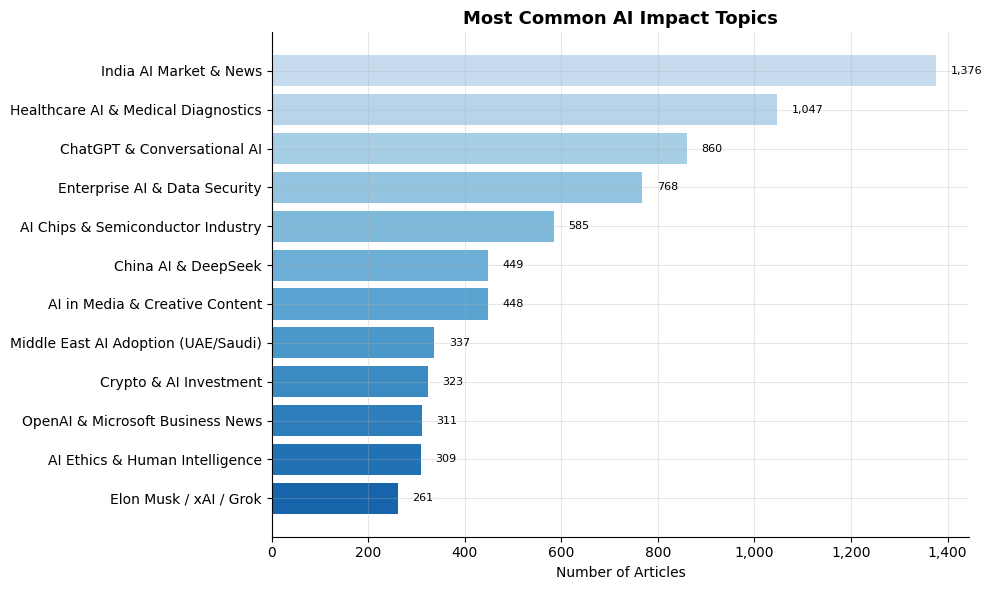

In [13]:
# ── figure: topic distribution ────────────────────────────────────────────────
top_topics = (
    df_clean_topics[df_clean_topics["topic"] != -1]["topic_label"]
    .value_counts()
    .head(12)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues_r([i / len(top_topics) * 0.6 + 0.2 for i in range(len(top_topics))])
bars = ax.barh(top_topics.index, top_topics.values, color=colors, edgecolor="none")
for bar, val in zip(bars, top_topics.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlabel("Number of Articles")
ax.set_title("Most Common AI Impact Topics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/topic_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

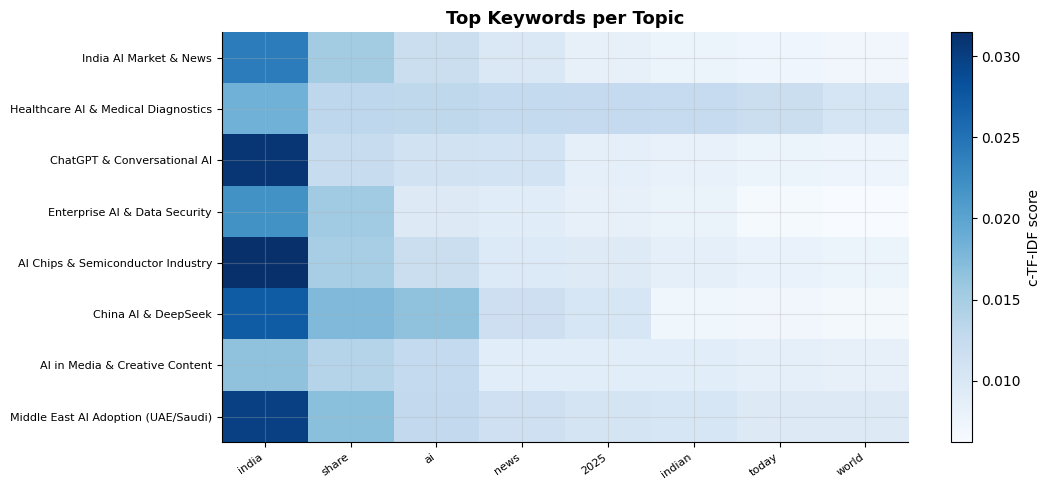

: 

In [ ]:
# ── figure: topic keyword heatmap ─────────────────────────────────────────────
import numpy as np

#only valid topic ID
valid_ids = [
    k for k, v in TOPIC_LABELS.items()
    if v not in NOISE_LABELS and v != "Other / Mixed Topic"
]

valid_counts = df_clean_topics[df_clean_topics["topic"].isin(valid_ids)]["topic"].value_counts()
top8_ids = valid_counts.head(8).index.tolist()

heat_data, row_labels, col_labels = [], [], []
for tid in top8_ids:
    words = topic_model.get_topic(tid)
    if not words:
        continue
    label = TOPIC_LABELS.get(tid, f"Topic {tid}")
    row_labels.append(label[:35])
    scores = [s for _, s in words[:8]]
    scores += [0] * (8 - len(scores))
    heat_data.append(scores)
    if not col_labels:
        col_labels = [w for w, _ in words[:8]]

mat = np.array(heat_data)
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(mat, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels, fontsize=8)
plt.colorbar(im, ax=ax, label="c-TF-IDF score")
ax.set_title("Top Keywords per Topic", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/topic_keyword_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()